# Acoustic 3D FWI(VP) with entire data

## Author: M. Alfarhan

This notebook performs acoustic 3D FWI parametrized in velocity using the
entire dataset. It is the three-dimensional counterpart of
`AcousticVel_L2_1stage` and follows the same workflow:

1. Set up acquisition (3×3 shot grid, 20×20 receiver grid on the surface)
2. Load and crop the 3D Overthrust model, build a smoothed starting model
3. Generate observed data with the true model
4. Compute the first gradient to derive a scaling factor (essential for
   L-BFGS to take well-conditioned steps in 3D)
5. Run L-BFGS-B with `PostProcessVP`
6. Compare true, initial, and inverted velocities and data residuals

Memory note: the 3D adjoint pass stores the forward wavefield, which is
much larger than in 2D. We use `factor=4` on the inversion engine to
subsample the saved wavefield, cutting memory ~4× at a small accuracy
cost. If your kernel still struggles, raise `factor` to 8 or enable
`checkpointing=True`.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy.optimize import minimize
from pylops.basicoperators import Identity

from devito import configuration

from devitofwi.waveengine.acoustic3d import AcousticWave3D
from devitofwi.loss.l2 import L2
from devitofwi.postproc.acoustic import PostProcessVP
from devitofwi.visual.volume import plot_slices

configuration['log-level'] = 'ERROR'


In [2]:
# Callback to track model error during the inversion
def fwi_callback(xk, vp_true, vp_error, vp_tmp):
    vp_tmp[0] = xk
    vp_error.append(np.linalg.norm((xk - vp_true.ravel()) / vp_true.ravel()))


## Parameters

The full Overthrust model is 801×801×187 at 25 m spacing. For a practical
single-machine FWI demo we crop a 150×150×100 sub-cube and downsample by 2
to land at 75×75×50 at 50 m spacing — about 3.75×3.75×2.5 km. The
acquisition is a 3×3 areal shot grid (9 shots) and a 20×20 surface
receiver grid (400 receivers).

In [3]:
# Model and acquisition parameters (in km, s, and Hz units)
par = {
    # Model cube extracted from the full Overthrust (after downsample x2)
    'nx': 75,   'dx': 0.050,  'ox': 0.0,
    'ny': 75,   'dy': 0.050,  'oy': 0.0,
    'nz': 50,   'dz': 0.050,  'oz': 0.0,
    # Shot grid (areal)
    'nsx': 3,   'dsx': 1.25,  'osx': 0.50,
    'nsy': 3,   'dsy': 1.25,  'osy': 0.50,
    'sz': 0.05,
    # Receiver grid (areal)
    'nrx': 20,  'drx': 0.18,  'orx': 0.05,
    'nry': 20,  'dry': 0.18,  'ory': 0.05,
    'rz': 0.05,
    # Time
    'tn': 3.0,
    # Source
    'freq': 8.0,
}

shape = (par['nx'], par['ny'], par['nz'])
spacing = (par['dx'], par['dy'], par['dz'])
origin = (par['ox'], par['oy'], par['oz'])
space_order = 4
nbl = 15           # absorbing-boundary thickness (cells)
factor = 4         # wavefield save subsampling factor

# Velocity model
path = '../../data/'
velocity_file = path + 'overthrust/overthrust.vites'


## Acquisition set-up

Sources arranged in an `nsx × nsy` areal grid near the surface; receivers
in an `nrx × nry` areal grid at the surface. Both grids are flattened into
1D arrays of length `nsrc` / `nrec` as expected by `AcousticWave3D`.

In [ ]:
# Axes
x = np.arange(par['nx']) * par['dx'] + par['ox']
y = np.arange(par['ny']) * par['dy'] + par['oy']
z = np.arange(par['nz']) * par['dz'] + par['oz']

# Shot grid -> flat 1D arrays
sx_1d = np.arange(par['nsx']) * par['dsx'] + par['osx']
sy_1d = np.arange(par['nsy']) * par['dsy'] + par['osy']
src_x = np.tile(sx_1d, par['nsy'])                     # (nsrc,)
src_y = np.repeat(sy_1d, par['nsx'])                   # (nsrc,)
src_z = np.full(par['nsx'] * par['nsy'], par['sz'])
nsrc = src_x.size

# Receiver grid -> flat 1D arrays
rx_1d = np.arange(par['nrx']) * par['drx'] + par['orx']
ry_1d = np.arange(par['nry']) * par['dry'] + par['ory']
rec_x = np.tile(rx_1d, par['nry'])                     # (nrec,)
rec_y = np.repeat(ry_1d, par['nrx'])                   # (nrec,)
rec_z = par['rz']                                      # scalar, promoted internally
nrec = rec_x.size

print(f'{nsrc} sources, {nrec} receivers')


9 sources, 400 receivers


Quick top-down view of the acquisition. The model footprint is shown
as a dashed rectangle so it's obvious whether the geometry sits inside the
cube.

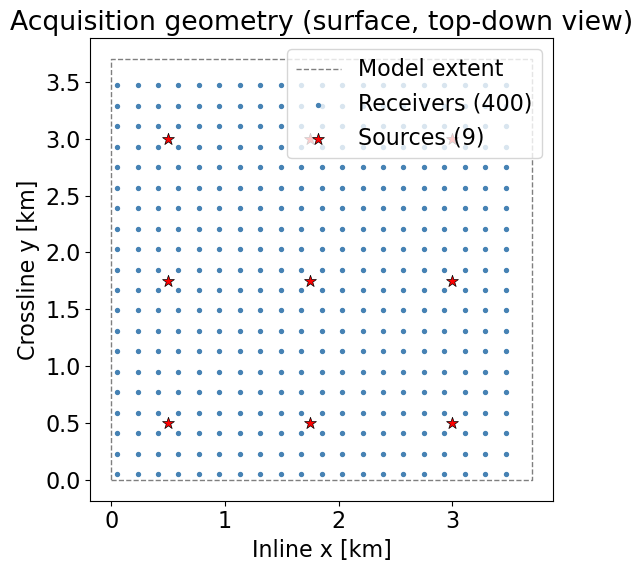

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
# Model footprint
ax.plot([x[0], x[-1], x[-1], x[0], x[0]],
        [y[0], y[0], y[-1], y[-1], y[0]],
        'k--', lw=1, alpha=0.5, label='Model extent')
# Receivers and sources
ax.scatter(rec_x, rec_y, s=8, c='steelblue', label=f'Receivers ({nrec})')
ax.scatter(src_x, src_y, s=80, c='red', marker='*',
           edgecolors='black', linewidths=0.5, label=f'Sources ({nsrc})')
ax.set_xlabel('Inline x [km]')
ax.set_ylabel('Crossline y [km]')
ax.set_title('Acquisition geometry (surface, top-down view)')
ax.legend(loc='upper right')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


## Velocity model

Load Overthrust, transpose to `(nx, ny, nz)`, and crop the working cube.

The file is stored as big-endian float32 in `(nz, ny, nx)` order with 25 m
spacing and m/s units. After loading and dividing by 1000 to get km/s, we
transpose to `(nx, ny, nz)` to match the engine's convention, then crop a
150×150×100 sub-cube and downsample by 2 to 75×75×50 at 50 m.

vp_true shape: (75, 75, 50)
vp_true range [km/s]: 2.52 – 5.50
percentile clip for plots: 2.74 – 5.50


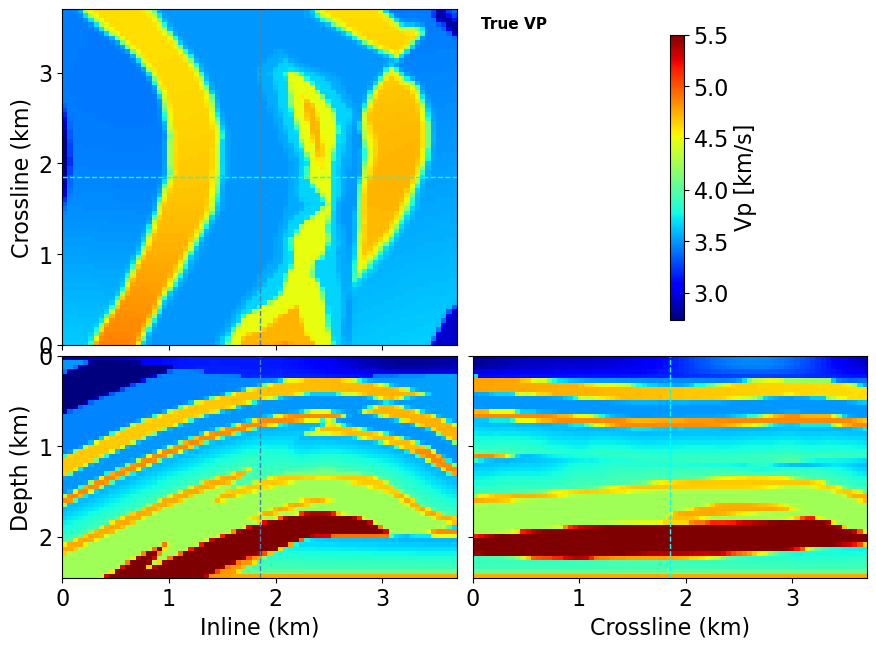

In [6]:
vp_raw = np.fromfile(velocity_file, dtype='>f4').astype(np.float32) / 1000.0
vp_raw = vp_raw.reshape(187, 801, 801)            # (nz, ny, nx) on disk
vp_full = np.transpose(vp_raw, (2, 1, 0))         # -> (nx, ny, nz)
del vp_raw

# Crop and downsample
vp_true = vp_full[200:350, 200:350, :100][::2, ::2, ::2].copy().astype(np.float32)
del vp_full
assert vp_true.shape == shape, f'expected {shape}, got {vp_true.shape}'

m_vmin, m_vmax = np.percentile(vp_true, [2, 98])
print(f'vp_true shape: {vp_true.shape}')
print(f'vp_true range [km/s]: {vp_true.min():.2f} – {vp_true.max():.2f}')
print(f'percentile clip for plots: {m_vmin:.2f} – {m_vmax:.2f}')

fig, _ = plot_slices(vp_true, x, y, z, title='True VP',
                     vmin=m_vmin, vmax=m_vmax)
plt.show()


### Initial model

A smoothed version of the true model, clipped to the same velocity range.

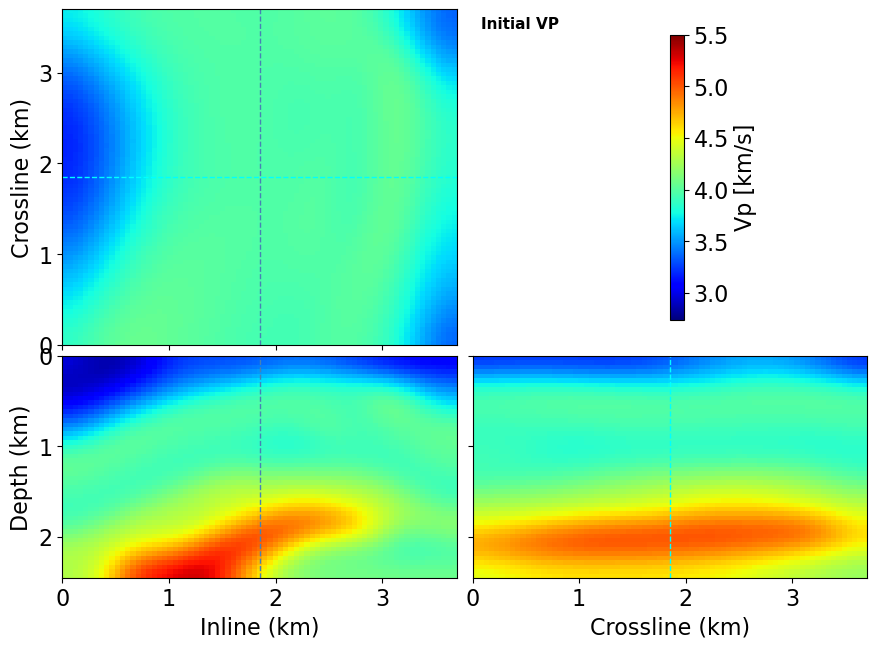

In [7]:
vp_init = gaussian_filter(vp_true, sigma=4.0).astype(np.float32)
vp_init = np.clip(vp_init, m_vmin, m_vmax)

fig, _ = plot_slices(vp_init, x, y, z, title='Initial VP',
                     vmin=m_vmin, vmax=m_vmax)
plt.show()


## Data modelling

Forward-model `nsrc` shots through the true velocity.

In [8]:
amod = AcousticWave3D(
    shape=shape, origin=origin, spacing=spacing,
    src_x=src_x, src_y=src_y, src_z=src_z,
    rec_x=rec_x, rec_y=rec_y, rec_z=rec_z,
    t0=0.0, tn=par['tn'],
    vp=vp_true,
    src_type='Ricker', f0=par['freq'],
    space_order=space_order, nbl=nbl,
    clearcache=False,
)

dobs, dtobs = amod.mod_allshots()
print(f'dobs shape: {dobs.shape}, dt = {dtobs * 1000:.3f} ms')


Modelling shots:   0%|          | 0/9 [00:00<?, ?it/s]

dobs shape: (9, 730, 400), dt = 4.117 ms


### Plot shot gathers

Three representative shots: first, middle, last. For each, we reshape the
flat receiver axis back to the `(nry, nrx)` patch and show an inline-receiver
slice at the middle crossline row.

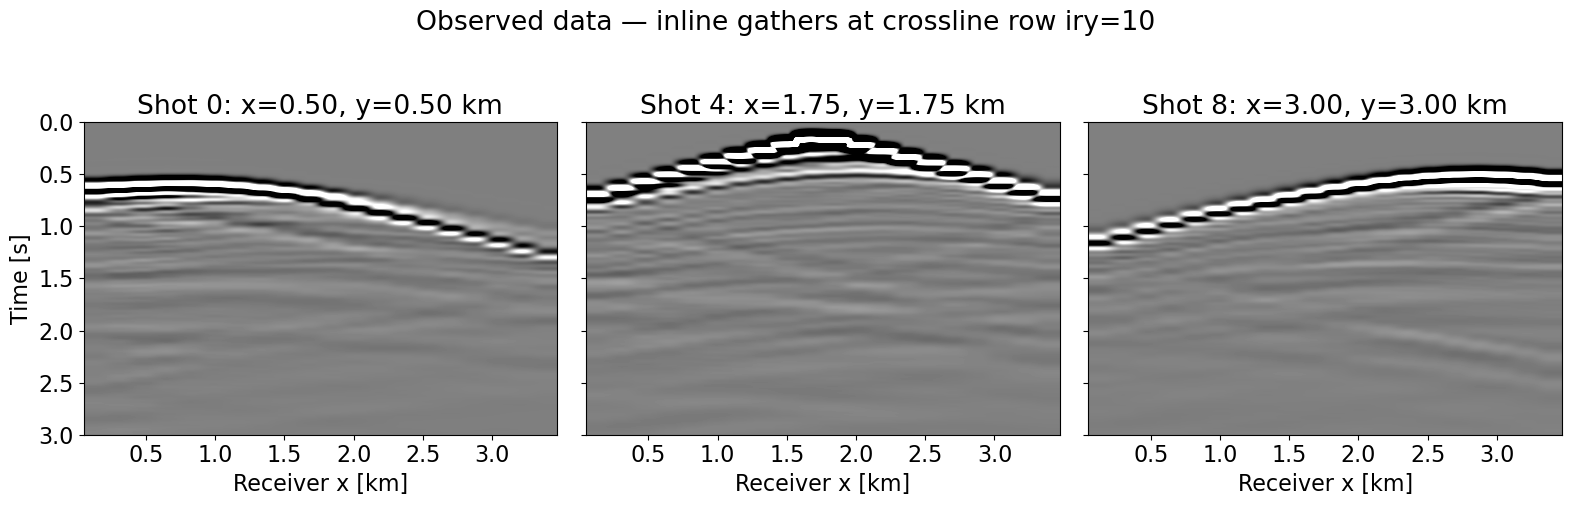

In [9]:
nt = dobs.shape[1]
t_axis = np.arange(nt) * dtobs
dobs_4d = dobs.reshape(nsrc, nt, par['nry'], par['nrx'])
d_vmin, d_vmax = np.percentile(dobs.ravel(), [2, 98])

ishots_plot = [0, nsrc // 2, nsrc - 1]
iry_mid = par['nry'] // 2

fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, ishot in zip(axs, ishots_plot):
    rec_slice = dobs_4d[ishot, :, iry_mid, :]
    ax.imshow(rec_slice, aspect='auto', cmap='gray',
              extent=[rx_1d[0], rx_1d[-1], t_axis[-1], t_axis[0]],
              vmin=-d_vmax, vmax=d_vmax)
    ax.set_title(f'Shot {ishot}: x={src_x[ishot]:.2f}, y={src_y[ishot]:.2f} km')
    ax.set_xlabel('Receiver x [km]')
axs[0].set_ylabel('Time [s]')
fig.suptitle(f'Observed data — inline gathers at crossline row iry={iry_mid}', y=1.02)
plt.tight_layout()
plt.show()


## Inversion with L-BFGS

Build the inversion engine with an `L2` loss against the observed data and
the same acquisition. We pass `vprange` (not `vp`) so the engine's internal
time axis is consistent with the observed-data time axis, and we set
`factor=4` to subsample the saved forward wavefield — essential for keeping
memory tractable in 3D.

In [10]:
l2loss = L2(Identity(int(np.prod(dobs.shape[1:]))),
            dobs.reshape(nsrc, -1))

ainv = AcousticWave3D(
    shape=shape, origin=origin, spacing=spacing,
    src_x=src_x, src_y=src_y, src_z=src_z,
    rec_x=rec_x, rec_y=rec_y, rec_z=rec_z,
    t0=0.0, tn=par['tn'],
    vprange=(vp_true.min(), vp_true.max()),
    src_type='Ricker', f0=par['freq'],
    space_order=space_order, nbl=nbl,
    factor=factor,
    loss=l2loss, clearcache=False,
)


### First gradient and scaling

Compute the first gradient on the initial model. Its peak value sets a
scaling factor used in `PostProcessVP` for the inversion

In [ ]:
postproc = PostProcessVP(scaling=1.0)
loss0, direction = ainv._loss_grad(vp_init, postprocess=postproc.apply)
scaling = direction.max()
print(f'first loss: {loss0:.3e}')
print(f'gradient max (scaling): {scaling:.3e}')

Computing gradient:   0%|          | 0/9 [00:00<?, ?it/s]

first loss: 2.788e-06
gradient max (scaling): 1.590e-09


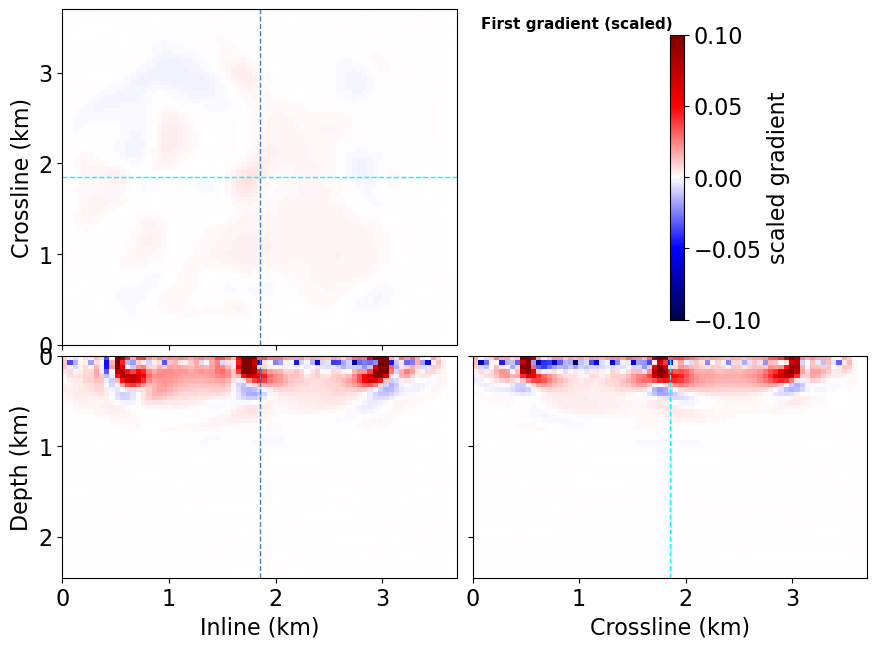

In [ ]:
# Plot the first gradient as three orthogonal slices
fig, _ = plot_slices(
    direction / scaling, x, y, z,
    vmin=-1e-1, vmax=1e-1,
    cmap='seismic',
    title='First gradient (scaled)',
    cbar_label='scaled gradient',
)
plt.show()

### Run L-BFGS-B

In [14]:
ftol = 1e-10
maxiter = 200
maxfun = 5000
vp_error = []
vp_tmp = [None]
convertvp = None
postproc = PostProcessVP(scaling=scaling)

nl = minimize(
    ainv.loss_grad, vp_init.ravel(),
    method='L-BFGS-B', jac=True,
    args=(convertvp, postproc.apply),
    bounds=[(m_vmin, m_vmax)] * vp_init.size,
    callback=lambda x: fwi_callback(x, vp_true=vp_true,
                                    vp_error=vp_error, vp_tmp=vp_tmp),
    options={'ftol': ftol, 'maxiter': maxiter, 'maxfun': maxfun, 'disp': True},
)


Computing gradient:   0%|          | 0/9 [00:00<?, ?it/s]

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =       281250     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.75301D+03    |proj g|=  2.41871D+00


Computing gradient:   0%|          | 0/9 [00:00<?, ?it/s]


At iterate    1    f=  1.22043D+03    |proj g|=  3.63772D-01


Computing gradient:   0%|          | 0/9 [00:00<?, ?it/s]

...


At iterate  198    f=  5.36754D+00    |proj g|=  1.35368D-02


Computing gradient:   0%|          | 0/9 [00:00<?, ?it/s]


At iterate  199    f=  5.35932D+00    |proj g|=  7.69344D-03


Computing gradient:   0%|          | 0/9 [00:00<?, ?it/s]


At iterate  200    f=  5.34955D+00    |proj g|=  1.11704D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
*****    200    205   5415     0  5792   1.117D-02   5.350D+00
  F =   5.3495528914294512     

STOP: TOTAL NO. of ITERATIONS REACHED LIMIT                 


## Results

In [15]:
nl


  message: STOP: TOTAL NO. of ITERATIONS REACHED LIMIT
  success: False
   status: 1
      fun: 5.349552891429451
        x: [ 2.743e+00  2.743e+00 ...  4.018e+00  4.040e+00]
      nit: 200
      jac: [ 3.084e-04  3.442e-04 ...  2.252e-06  1.148e-06]
     nfev: 205
     njev: 205
 hess_inv: <281250x281250 LbfgsInvHessProduct with dtype=float64>

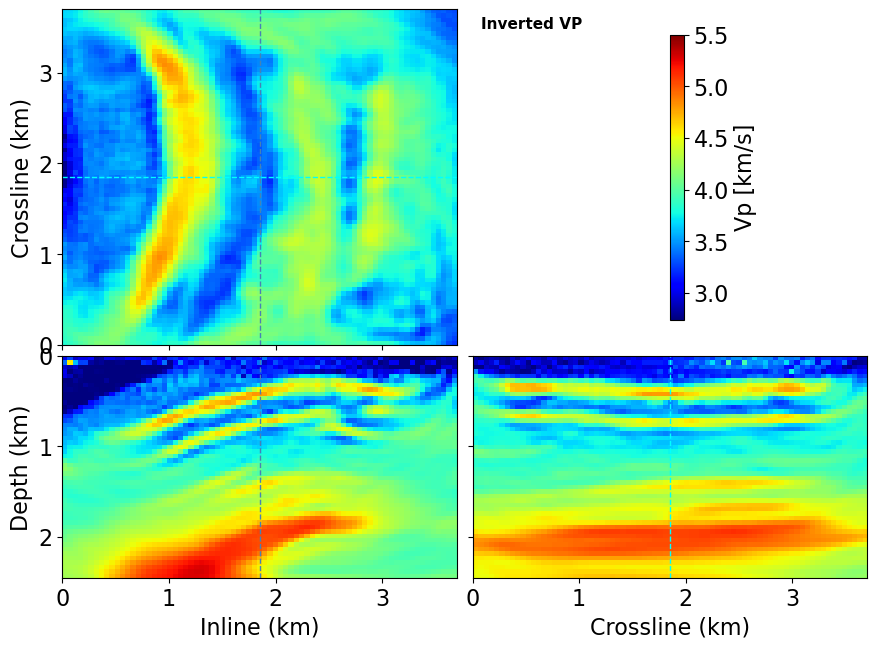

In [16]:
vp_inv = nl.x.reshape(shape).astype(np.float32)

fig, _ = plot_slices(vp_inv, x, y, z, title='Inverted VP',
                     vmin=m_vmin, vmax=m_vmax)
plt.show()


### Difference: true – inverted

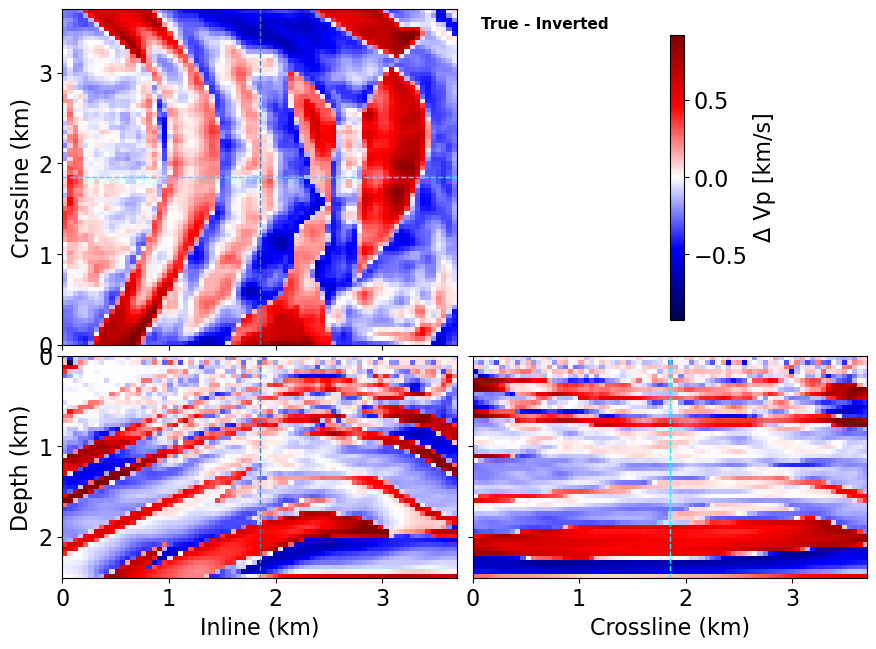

mean abs error: 0.271 km/s
max abs error:  2.444 km/s
relative model error: 0.0867


In [17]:
diff = vp_true - vp_inv
dlim = max(0.5, np.percentile(np.abs(diff), 99))
fig, _ = plot_slices(diff, x, y, z, title='True - Inverted',
                     vmin=-dlim, vmax=dlim, cmap='seismic',
                     cbar_label='Δ Vp [km/s]')
plt.show()

print(f'mean abs error: {np.abs(diff).mean():.3f} km/s')
print(f'max abs error:  {np.abs(diff).max():.3f} km/s')
print(f'relative model error: {np.linalg.norm(diff) / np.linalg.norm(vp_true):.4f}')


### Loss and model-error history

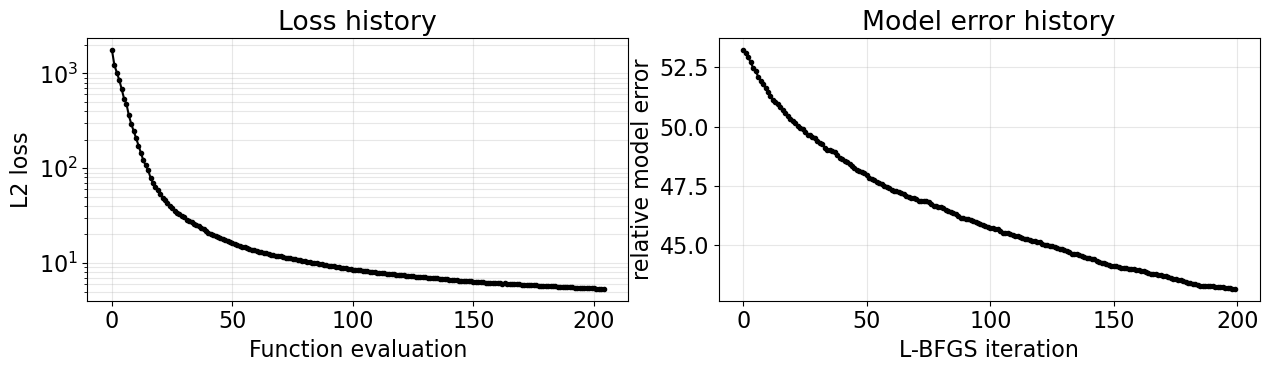

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].semilogy(ainv.losshistory, 'k', marker='o', ms=3)
axs[0].set_xlabel('Function evaluation')
axs[0].set_ylabel('L2 loss')
axs[0].set_title('Loss history')
axs[0].grid(True, which='both', alpha=0.3)

axs[1].plot(vp_error, 'k', marker='o', ms=3)
axs[1].set_xlabel('L-BFGS iteration')
axs[1].set_ylabel('relative model error')
axs[1].set_title('Model error history')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Modelled data with the inverted model

Re-model the data with `vp_inv` (sampled to the observed-data `dt`) and
compare to the observed data.

In [19]:
ainvfinal = AcousticWave3D(
    shape=shape, origin=origin, spacing=spacing,
    src_x=src_x, src_y=src_y, src_z=src_z,
    rec_x=rec_x, rec_y=rec_y, rec_z=rec_z,
    t0=0.0, tn=par['tn'],
    vp=vp_inv,
    src_type='Ricker', f0=par['freq'],
    space_order=space_order, nbl=nbl,
    clearcache=False,
)
dinv, _ = ainvfinal.mod_allshots(dt=dtobs)
print(f'dinv shape: {dinv.shape}')

# Reshape for plotting
dinv_4d = dinv.reshape(nsrc, dinv.shape[1], par['nry'], par['nrx'])


Modelling shots:   0%|          | 0/9 [00:00<?, ?it/s]

dinv shape: (9, 730, 400)


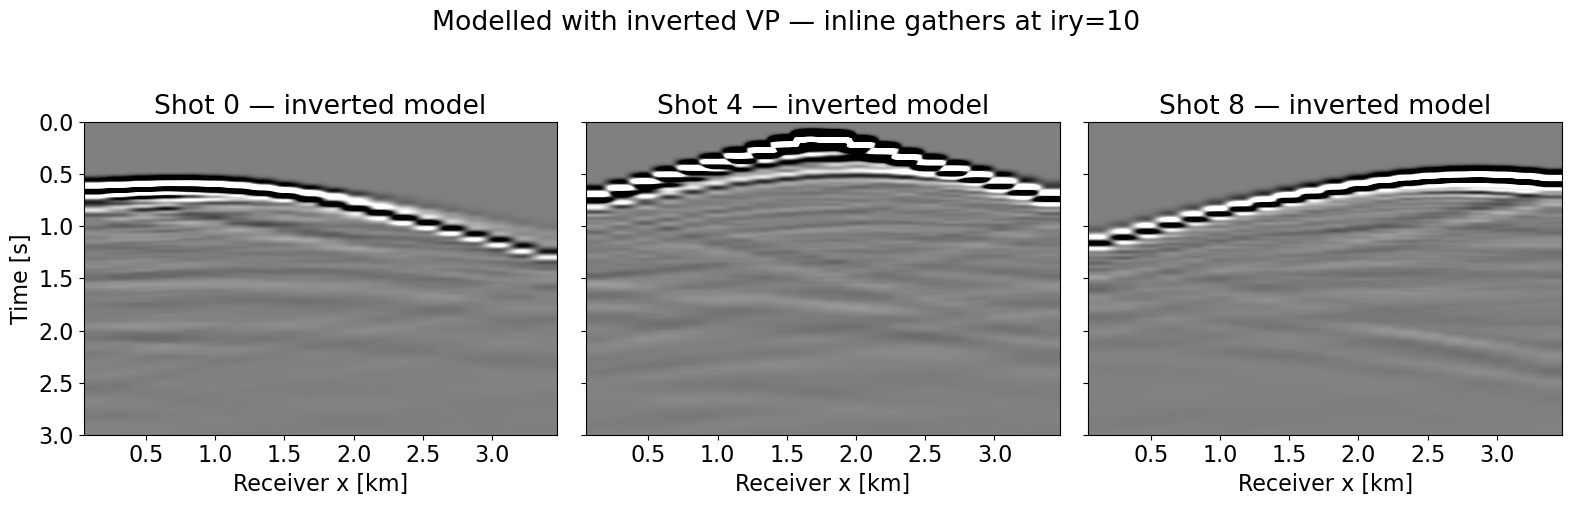

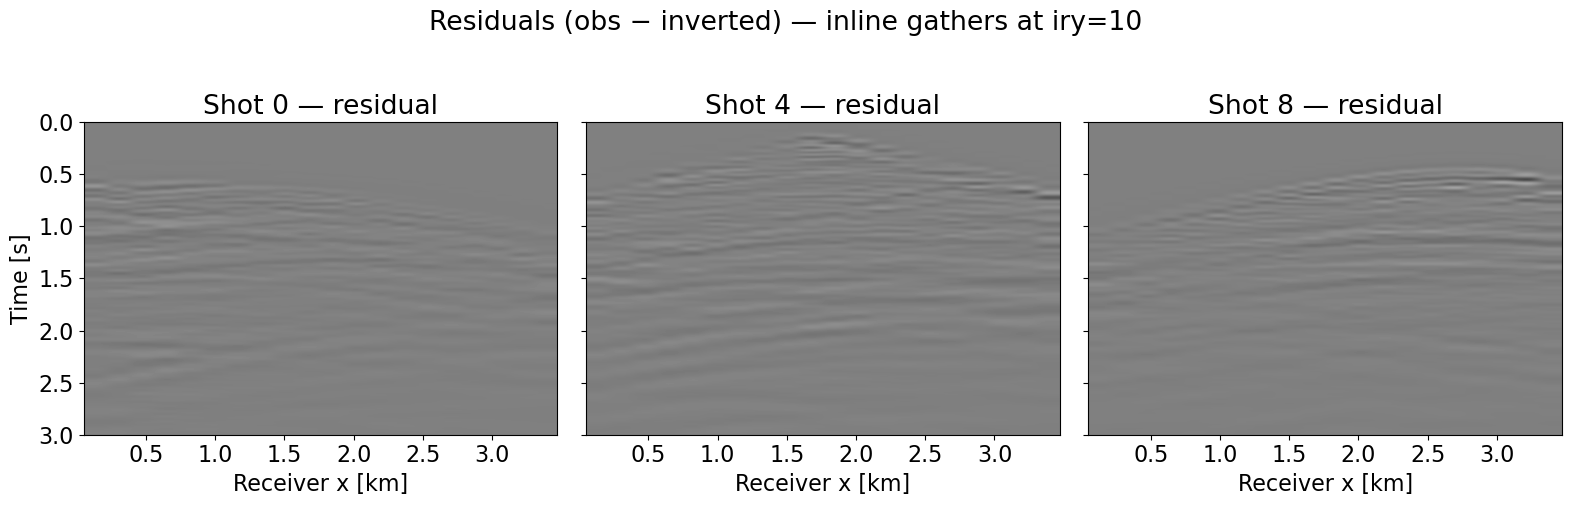

In [20]:
# Modelled data
fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, ishot in zip(axs, ishots_plot):
    rec_slice = dinv_4d[ishot, :, iry_mid, :]
    ax.imshow(rec_slice, aspect='auto', cmap='gray',
              extent=[rx_1d[0], rx_1d[-1], t_axis[-1], t_axis[0]],
              vmin=-d_vmax, vmax=d_vmax)
    ax.set_title(f'Shot {ishot} — inverted model')
    ax.set_xlabel('Receiver x [km]')
axs[0].set_ylabel('Time [s]')
fig.suptitle(f'Modelled with inverted VP — inline gathers at iry={iry_mid}', y=1.02)
plt.tight_layout()
plt.show()

# Residuals
fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, ishot in zip(axs, ishots_plot):
    rec_slice = dobs_4d[ishot, :, iry_mid, :] - dinv_4d[ishot, :, iry_mid, :]
    ax.imshow(rec_slice, aspect='auto', cmap='gray',
              extent=[rx_1d[0], rx_1d[-1], t_axis[-1], t_axis[0]],
              vmin=-d_vmax, vmax=d_vmax)
    ax.set_title(f'Shot {ishot} — residual')
    ax.set_xlabel('Receiver x [km]')
axs[0].set_ylabel('Time [s]')
fig.suptitle(f'Residuals (obs − inverted) — inline gathers at iry={iry_mid}', y=1.02)
plt.tight_layout()
plt.show()
